c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Confusion Matrix:
 [[175  37]
 [ 13 344]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



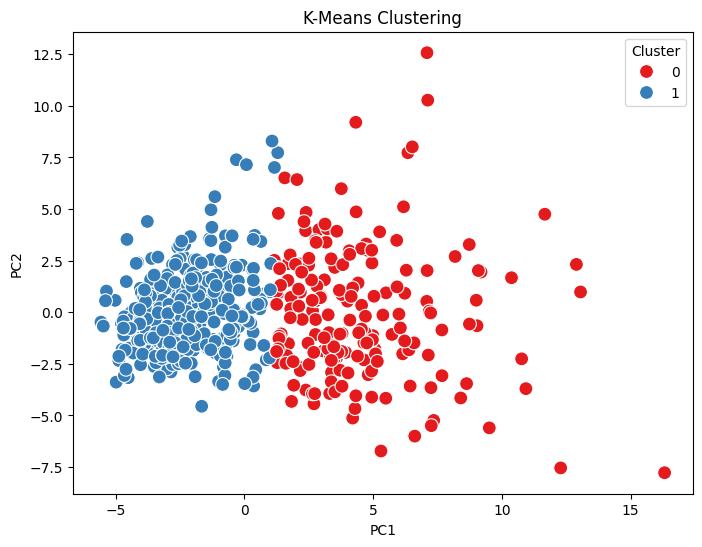

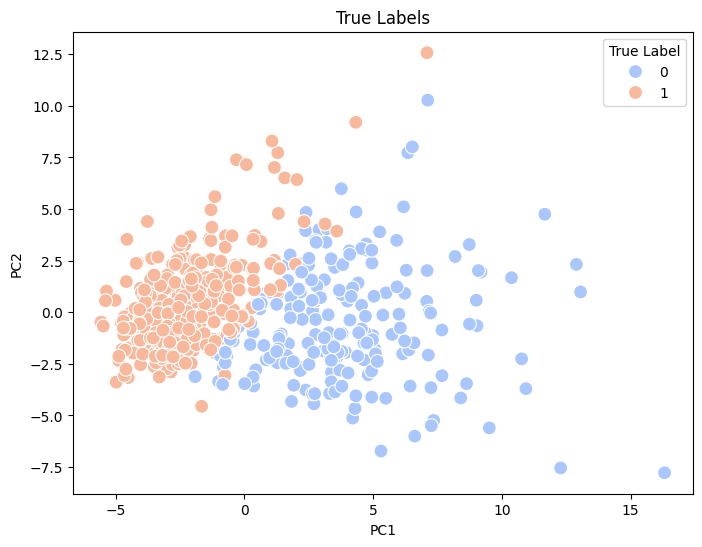

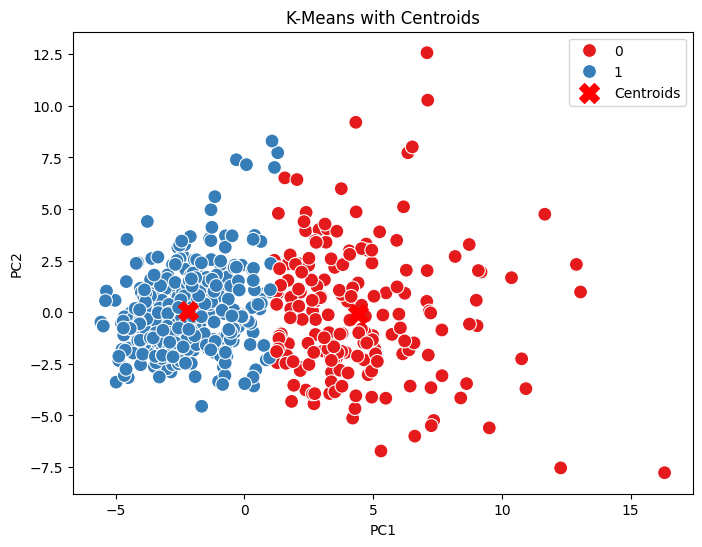

In [1]:
#lab10
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
X, y = data.data, data.target

X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_scaled)
clusters = kmeans.labels_

print("Confusion Matrix:\n", confusion_matrix(y, clusters))
print("\nClassification Report:\n", classification_report(y, clusters))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
df["Cluster"], df["True Label"] = clusters, y

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=100)
plt.title("K-Means Clustering")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="True Label", palette="coolwarm", s=100)
plt.title("True Labels")
plt.show()

centers = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=100)
plt.scatter(centers[:,0], centers[:,1], s=200, c="red", marker="X", label="Centroids")
plt.title("K-Means with Centroids")
plt.legend()
plt.show()